In [52]:
import kagglehub

path = kagglehub.dataset_download("beatoa/spamassassin-public-corpus")
print(path)

C:\Users\Dell\.cache\kagglehub\datasets\beatoa\spamassassin-public-corpus\versions\2


In [53]:
import os

print(os.listdir(path))

['easy_ham', 'hard_ham', 'spam_2']


In [54]:
import os

for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Number of files:", len(files))
    break

Folder: C:\Users\Dell\.cache\kagglehub\datasets\beatoa\spamassassin-public-corpus\versions\2
Number of files: 0


In [55]:
import os

emails = []
labels = []

spam_2_path = os.path.join(path, "spam_2")
easy_ham_path = os.path.join(path, "easy_ham")
hard_ham_path = os.path.join(path, "hard_ham")

def read_emails(folder_path, label):
    for root, dirs, files in os.walk(folder_path):
        
        # ❌ Skip __MACOSX folders
        if "__MACOSX" in root:
            continue
        
        for file in files:
            
            # ❌ Skip hidden/system files
            if file.startswith('.'):
                continue
            
            file_path = os.path.join(root, file)
            
            if os.path.isfile(file_path):
                try:
                    with open(file_path, "r", encoding="latin-1") as f:
                        emails.append(f.read())
                        labels.append(label)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")

# Read datasets
read_emails(spam_2_path, 1)
read_emails(easy_ham_path, 0)
read_emails(hard_ham_path, 0)

print(f"Total emails: {len(emails)}")
print(f"Total labels: {len(labels)}")

Total emails: 4198
Total labels: 4198


In [56]:
import pandas as pd
df = pd.DataFrame({"email": emails, "label": labels})
print(df.head())

                                               email  label
0  From ilug-admin@linux.ie  Tue Aug  6 11:51:02 ...      1
1  From lmrn@mailexcite.com  Mon Jun 24 17:03:24 ...      1
2  From amknight@mailexcite.com  Mon Jun 24 17:03...      1
3  From jordan23@mailexcite.com  Mon Jun 24 17:04...      1
4  From merchantsworld2001@juno.com  Tue Aug  6 1...      1


In [57]:
df['label'].value_counts()

label
0    2801
1    1397
Name: count, dtype: int64

In [58]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'\W+', ' ', text)  # remove special chars
    
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

df['clean_text'] = df['email'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['label'], test_size=0.2, random_state=42
)

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [61]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

In [62]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

In [63]:
from sklearn.metrics import classification_report, confusion_matrix

print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))
print("SVM:\n", classification_report(y_test, y_pred_svm))

print("Confusion Matrix (NB):\n", confusion_matrix(y_test, y_pred_nb))

Naive Bayes:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97       536
           1       0.93      0.96      0.95       304

    accuracy                           0.96       840
   macro avg       0.95      0.96      0.96       840
weighted avg       0.96      0.96      0.96       840

SVM:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       536
           1       0.99      1.00      1.00       304

    accuracy                           1.00       840
   macro avg       1.00      1.00      1.00       840
weighted avg       1.00      1.00      1.00       840

Confusion Matrix (NB):
 [[514  22]
 [ 11 293]]


In [64]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)

In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential()

# ❌ removed input_length (warning fix)
model.add(Embedding(input_dim=5000, output_dim=64))

model.add(LSTM(64))

# ✅ Add dropout to reduce overfitting
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# ✅ Add validation_split here (VERY IMPORTANT)
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.8649 - loss: 0.3270 - val_accuracy: 0.9509 - val_loss: 0.1477
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.9806 - loss: 0.0741 - val_accuracy: 0.9747 - val_loss: 0.0897
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9918 - loss: 0.0342 - val_accuracy: 0.9732 - val_loss: 0.0895
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9937 - loss: 0.0188 - val_accuracy: 0.9777 - val_loss: 0.0750
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9985 - loss: 0.0089 - val_accuracy: 0.9807 - val_loss: 0.0940
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.9985 - loss: 0.0072 - val_accuracy: 0.9792 - val_loss: 0.0838
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9966 - loss: 0.0134 - val_accuracy: 0.9747 - val_loss: 0.0994
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.9978 - loss: 0.0092 - val_accuracy: 0.9777 - 

In [66]:
loss, acc = model.evaluate(X_test_pad, y_test)
print("LSTM Accuracy:", acc)

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9857 - loss: 0.0784
LSTM Accuracy: 0.9857142567634583


In [67]:
train_loss, train_acc = model.evaluate(X_train_pad, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.993746280670166
Test Accuracy: 0.9857142567634583


In [68]:
from sklearn.metrics import f1_score

y_pred_lstm = (model.predict(X_test_pad) > 0.5).astype("int32")

print("F1 Score:", f1_score(y_test, y_pred_lstm))

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step
F1 Score: 0.980327868852459


In [69]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM", "LSTM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm),
        acc  # from LSTM evaluation
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, (model.predict(X_test_pad) > 0.5).astype("int32"))
    ]
})

print(results)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
         Model  Accuracy  F1 Score
0  Naive Bayes  0.960714  0.946688
1          SVM  0.996429  0.995090
2         LSTM  0.985714  0.980328


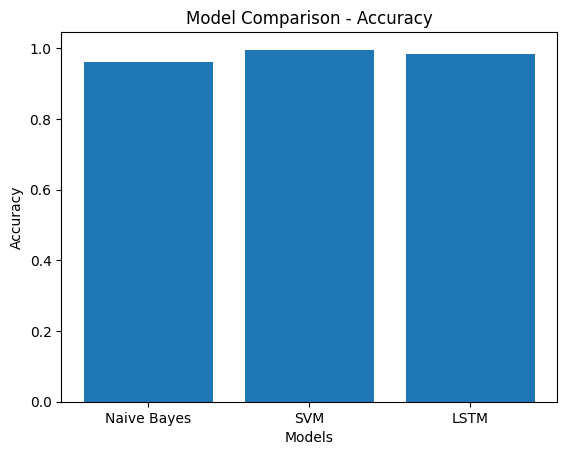

In [70]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["Accuracy"])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")
plt.show()

In [71]:
print("Train Accuracy (SVM):", svm.score(X_train_tfidf, y_train))
print("Test Accuracy (SVM):", svm.score(X_test_tfidf, y_test))

Train Accuracy (SVM): 0.9982132221560452
Test Accuracy (SVM): 0.9964285714285714


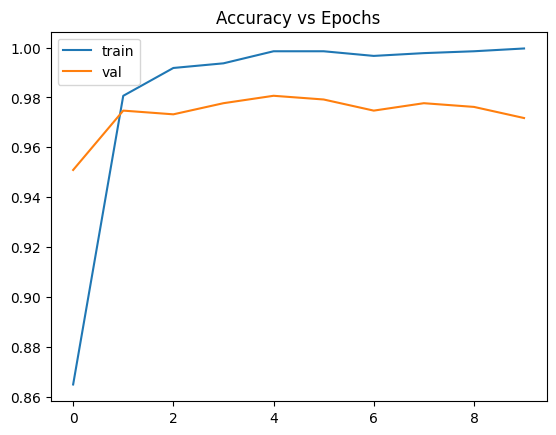

In [72]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.title('Accuracy vs Epochs')
plt.show()

The model learns effectively in early epochs, but later epochs show slight overfitting as training accuracy increases while validation accuracy stabilizes.

In [73]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(svm, X_train_tfidf, y_train, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.9892799481938827


In [74]:
def predict_email(text):
    # preprocess
    cleaned = clean_text(text)
    
    # convert to TF-IDF
    vector = tfidf.transform([cleaned])
    
    # predict
    prediction = svm.predict(vector)[0]
    
    return "Spam" if prediction == 1 else "Not Spam"

In [75]:
email = "Congratulations! You have won a free lottery. Click here now!"
print(predict_email(email))

Spam


In [76]:
samples = [
    "Meeting scheduled at 10am tomorrow",
    "You won a free iPhone!!! Click now",
    "Please find attached the project report"
]

for s in samples:
    print(s, " --> ", predict_email(s))

Meeting scheduled at 10am tomorrow  -->  Not Spam
You won a free iPhone!!! Click now  -->  Spam
Please find attached the project report  -->  Not Spam


In [77]:
import pickle

# Save SVM model (NOT LSTM)
with open("model.pkl", "wb") as f:
    pickle.dump(svm, f)

# Save TF-IDF vectorizer (NOT Keras tokenizer)
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("✅ SVM model and TF-IDF vectorizer saved!")

✅ SVM model and TF-IDF vectorizer saved!


In [78]:
import pickle
test = pickle.load(open("model.pkl", "rb"))
print(test.probability)  # must print True

True
